# Visualisation of Baseline

In [10]:
import glob
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

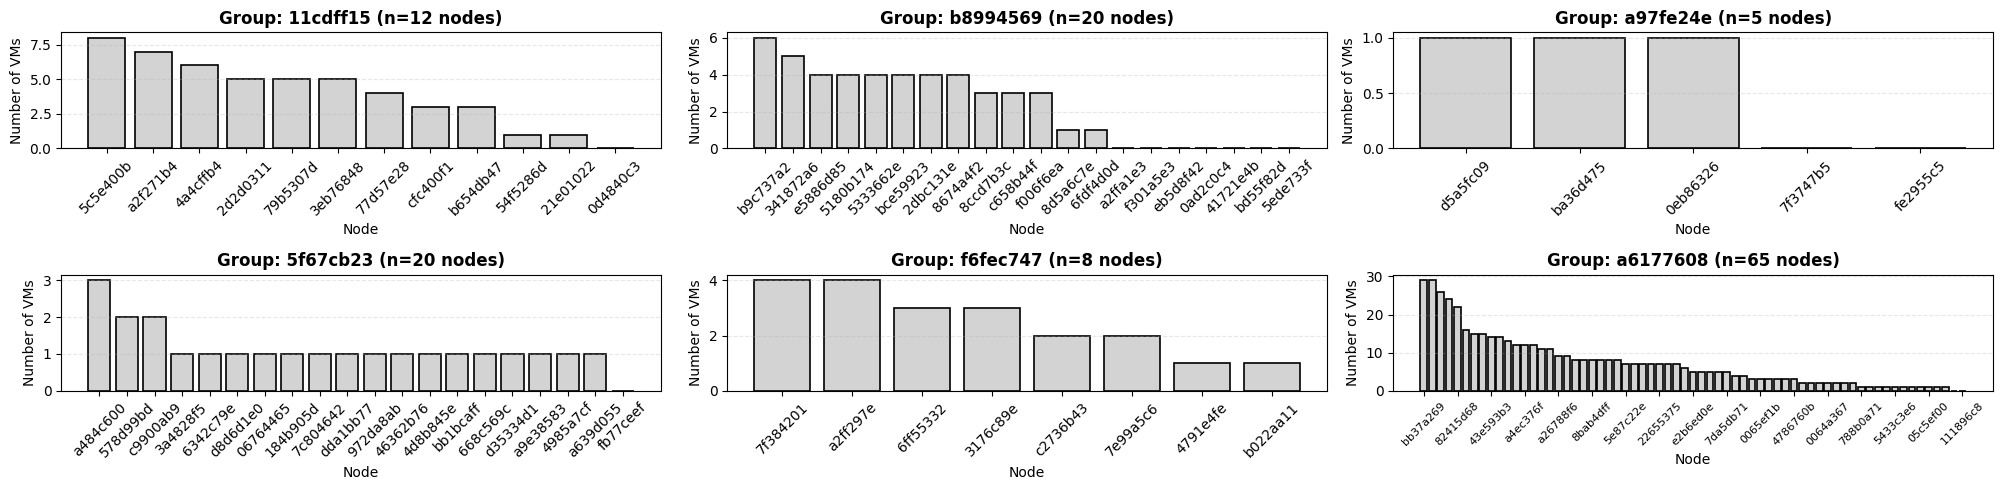

In [25]:
# a grid plot, one per node group
# each plot has x-axis of nodes in the group and y axis of number of vms on that node
node_groups_csv = pd.read_csv("/Users/biancachiusano/Desktop/uva/thesis/energy-aware-vm-consolidation/datasets/cloud_energy_consumption/node-groups/2024-12-14T000000Z_2025-04-13T235959Z/cleaned_node_groups.csv")
node_groups = node_groups_csv["node_group"].unique()

data = {}
for group in node_groups:
    nodes_in_group = glob.glob(f"/Users/biancachiusano/Desktop/uva/thesis/energy-aware-vm-consolidation/datasets/cloud_energy_consumption/nodes/2024-12-14T000000Z_2025-04-13T235959Z/{group}/*")
    node_names = [Path(path).stem for path in nodes_in_group]
    
    group_data = {}
    for node in node_names:
        vms_per_node = glob.glob(f"/Users/biancachiusano/Desktop/uva/thesis/energy-aware-vm-consolidation/datasets/cloud_energy_consumption/nodes-vms/2024-12-14T000000Z_2025-04-13T235959Z/{group}/{node}/*")
        vm_count = len(vms_per_node)
        group_data[node] = vm_count
    
    data[group] = group_data

# Create plot
fig, axes = plt.subplots(2, 3, figsize=(20, 5))
axes = axes.flatten()

for idx, (group, nodes_vms) in enumerate(data.items()):
    # Sort nodes by VM count (descending) to show most-loaded nodes first
    sorted_nodes = sorted(nodes_vms.items(), key=lambda x: x[1], reverse=True)
    node_list = [node for node, _ in sorted_nodes]
    vm_counts = [count for _, count in sorted_nodes]
    
    # Plot
    axes[idx].bar(node_list, vm_counts, color='lightgray', edgecolor='black', linewidth=1.2)
    axes[idx].set_title(f"Group: {group} (n={len(vm_counts)} nodes)", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Node", fontsize=10)
    axes[idx].set_ylabel("Number of VMs", fontsize=10)
    axes[idx].tick_params(axis='x', rotation=45)

    if len(node_list) > 30:
        step = max(1, len(node_list) // 15)  # Show ~15 labels max
        axes[idx].set_xticks(range(0, len(node_list), step))
        axes[idx].set_xticklabels([node_list[i] for i in range(0, len(node_list), step)], fontsize=8)
    
    # Improve readability
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')

#plt.suptitle("IFCA Cloud Data Center: VM Distribution by Node Group", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("ifca_datacenter_vm_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# Visualisations of Results

In [1]:
import matplotlib.pyplot as plt
import duckdb as ddb

# Current states, how the VMs are placed and when they are active
# plot of total power consumption over time, comparing the original state and the simulated consolidation state
# plot of the number of active hosts over time, comparing the original state and the simulated consolidation state
# for a specific node, its vm count over time, comparing the original state and the simulated consolidation state

In [2]:
con = ddb.connect(database=':memory:')
con.execute(f"""CREATE OR REPLACE VIEW node_snapshot AS SELECT * FROM read_parquet('/Users/biancachiusano/Desktop/uva/thesis/energy-aware-vm-consolidation/datasets/cloud_energy_consumption/processed/node_snapshot.parquet')""")
con.execute(f"""CREATE OR REPLACE VIEW simulation_snapshot AS SELECT * FROM read_parquet('/Users/biancachiusano/Desktop/uva/thesis/energy-aware-vm-consolidation/datasets/cloud_energy_consumption/processed/simulated_consolidation.parquet')""")

### Total power consumption over time (for energy efficiency)

In [3]:
baseline_power = con.execute("""
    SELECT
        timestamp,
        SUM(ipmi_system_power_watts) AS total_power
    FROM node_snapshot
    GROUP BY timestamp
    ORDER BY timestamp
""").df()

simulated_power = con.execute("""
    SELECT
        timestamp,
        SUM(simulated_power) AS total_power
    FROM simulation_snapshot
    GROUP BY timestamp
    ORDER BY timestamp
""").df()

In [4]:
power_df = baseline_power.merge(
    simulated_power,
    on="timestamp",
    suffixes=("_baseline", "_simulated")
)

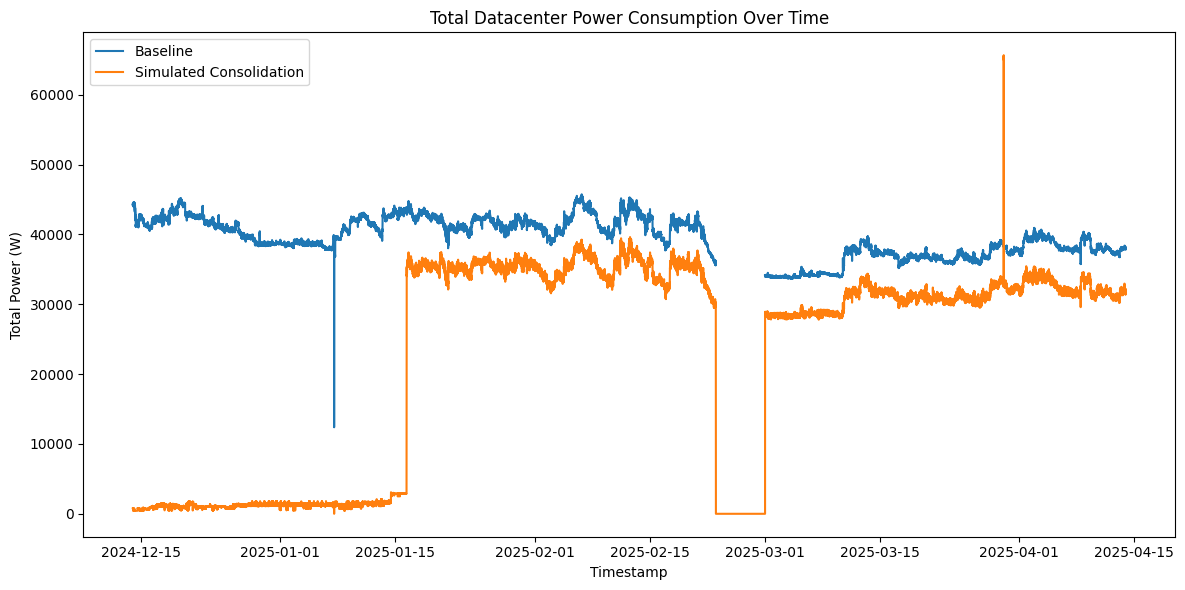

In [5]:
plt.figure(figsize=(12,6))

plt.plot(
    power_df["timestamp"],
    power_df["total_power_baseline"],
    label="Baseline"
)

plt.plot(
    power_df["timestamp"],
    power_df["total_power_simulated"],
    label="Simulated Consolidation"
)

plt.xlabel("Timestamp")
plt.ylabel("Total Power (W)")
plt.title("Total Datacenter Power Consumption Over Time")

plt.legend()
plt.tight_layout()
plt.show()

### Power Saving Distribution

In [7]:
power_df["power_savings"] = (power_df["total_power_baseline"]- power_df["total_power_simulated"])

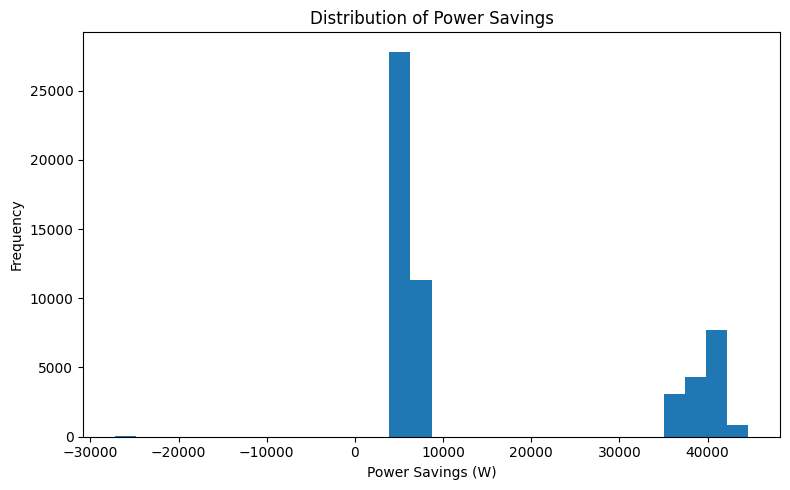

In [8]:
plt.figure(figsize=(8,5))

plt.hist(power_df["power_savings"], bins=30)

plt.xlabel("Power Savings (W)")
plt.ylabel("Frequency")
plt.title("Distribution of Power Savings")

plt.tight_layout()
plt.show()

### Active Hosts over time

In [9]:
baseline_hosts = con.execute("""
    SELECT
        timestamp,
        COUNT(*) AS active_hosts
    FROM node_snapshot
    WHERE vm_count > 0
    GROUP BY timestamp
    ORDER BY timestamp
""").df()

simulated_hosts = con.execute("""
    SELECT
        timestamp,
        COUNT(*) AS active_hosts
    FROM simulation_snapshot
    WHERE simulated_power > 0
    GROUP BY timestamp
    ORDER BY timestamp
""").df()

In [10]:
active_hosts = baseline_hosts.merge(
    simulated_hosts,
    on="timestamp",
    suffixes=("_baseline", "_simulated")
)

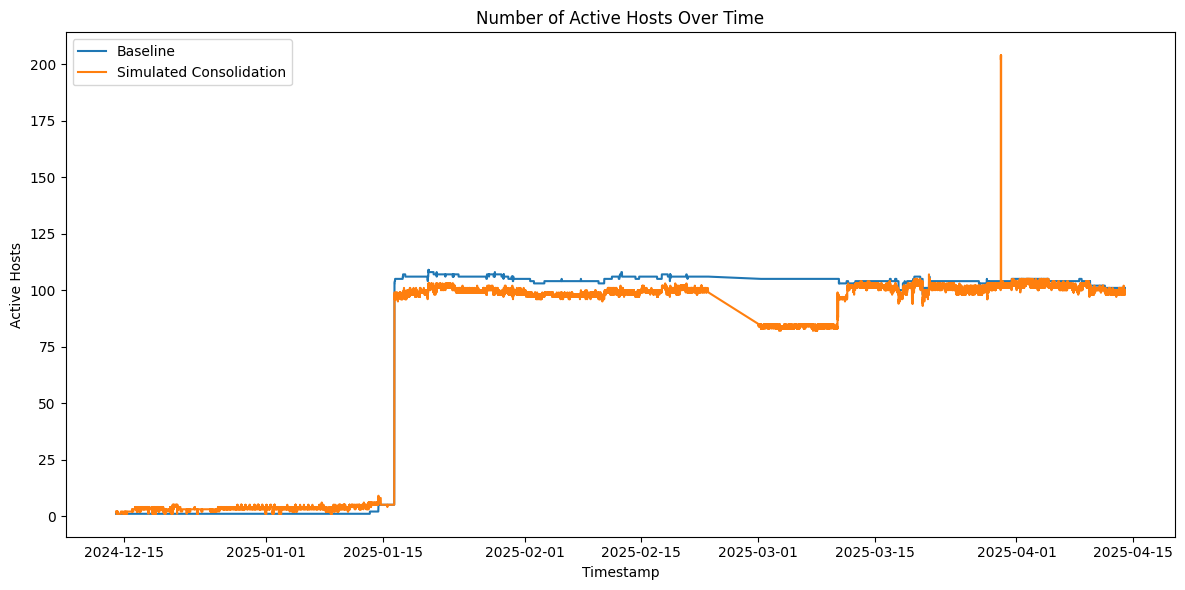

In [11]:
plt.figure(figsize=(12,6))

plt.plot(
    active_hosts["timestamp"],
    active_hosts["active_hosts_baseline"],
    label="Baseline"
)

plt.plot(
    active_hosts["timestamp"],
    active_hosts["active_hosts_simulated"],
    label="Simulated Consolidation"
)

plt.xlabel("Timestamp")
plt.ylabel("Active Hosts")
plt.title("Number of Active Hosts Over Time")

plt.legend()
plt.tight_layout()
plt.show()

### Number of Migrations
Because im not sure if the simulated df has a lower average power consumption because of the migrations or because its setting nodes with no VMs to 0W power consumption (which would no be ideal for scope of this thesis)

In [ ]:
# use vm count for node snapshot
# use vm id list for the simulation snapshot

# Specific Examples of Before and After Consolidation

In [ ]:
# show before consolidation
# show after consolidation

# Specific Examples

First three timestamps

In [15]:
con = ddb.connect(database=':memory:')
con.execute(f"""CREATE OR REPLACE VIEW node_snapshot AS SELECT * FROM read_parquet('/Users/biancachiusano/Desktop/uva/thesis/energy-aware-vm-consolidation/datasets/cloud_energy_consumption/processed/node_snapshot.parquet')""")
con.execute(f"""CREATE OR REPLACE VIEW simulation_snapshot AS SELECT * FROM read_parquet('/Users/biancachiusano/Desktop/uva/thesis/energy-aware-vm-consolidation/datasets/cloud_energy_consumption/processed/simulated_example.parquet')""")

In [ ]:
con.execute("""SELECT * FROM node_snapshot LIMIT 20 WHERE timestamp = '2023-01-01 00:00:00'""").df()


,timestamp,node_name,cpu_usage_percent,ipmi_system_power_watts,cpu_capacity,power_capacity,memory_capacity_mb,memory_available_mb,host_state,vm_count,vm_power_allocated,cpu_allocated,memory_allocated_mb,baseline_power,simulated_power
0,2024-12-14 01:00:00+01:00,0049db0c,0.21,415.00,128.0,1100.0,386653.667969,289728.684245,underloaded,0,0.0,0.0,0.0,415.00,415.00
1,2024-12-14 01:00:00+01:00,0064a367,99.88,784.17,128.0,1100.0,386653.667969,1589.156901,overloaded,0,0.0,0.0,0.0,784.17,784.17
2,2024-12-14 01:00:00+01:00,0065ef1b,0.03,410.00,128.0,1100.0,386653.664062,366362.100911,underloaded,0,0.0,0.0,0.0,410.00,410.00
3,2024-12-14 01:00:00+01:00,05c5ef00,18.52,465.00,128.0,1100.0,386653.667969,1432.229167,normal,0,0.0,0.0,0.0,465.00,465.00
4,2024-12-14 01:00:00+01:00,0861be67,0.01,400.83,128.0,1100.0,386653.667969,374960.932292,underloaded,0,0.0,0.0,0.0,400.83,400.83
5,2024-12-14 01:00:00+01:00,0ad2c0c4,0.02,60.00,96.0,2000.0,192948.554688,182133.159505,underloaded,0,0.0,0.0,0.0,60.00,60.00
6,2024-12-14 01:00:00+01:00,0eb86326,0.53,NaN,80.0,750.0,773701.632812,590891.141276,underloaded,0,0.0,0.0,0.0,NaN,NaN
7,2024-12-14 01:00:00+01:00,111896c8,0.01,414.17,128.0,1100.0,386653.664062,375901.202474,underloaded,0,0.0,0.0,0.0,414.17,414.17
8,2024-12-14 01:00:00+01:00,1125a01c,0.01,405.00,128.0,1100.0,386653.867188,375765.723958,underloaded,0,0.0,0.0,0.0,405.00,405.00
9,2024-12-14 01:00:00+01:00,13a6f4c8,0.47,416.67,128.0,1100.0,386653.667969,273138.533854,underloaded,0,0.0,0.0,0.0,416.67,416.67


In [17]:
con.execute("""SELECT * FROM simulation_snapshot LIMIT 20""").df()

,timestamp,node_name,cpu_usage_percent,ipmi_system_power_watts,cpu_capacity,power_capacity,memory_capacity_mb,memory_available_mb,host_state,vm_count,vm_power_allocated,cpu_allocated,memory_allocated_mb,baseline_power,simulated_power,vm_ids,vm_cpus,vm_memories_mb,vm_powers
0,2025-02-12 11:57:00+01:00,0049db0c,0.33,422.50,128.0,1100.0,386653.667969,260861.527344,underloaded,13,0.50,128.0,315500.0,421.97,422.47,"[161a1da3, 04430fb0, 5183f3b2, 4ff41670, 14e04...","[4.0, 8.0, 64.0, 1.0, 4.0, 4.0, 4.0, 2.0, 1.0,...","[11000.0, 23000.0, 185000.0, 2000.0, 7500.0, 1...","[0.23, 0.17, 0.03, 0.02, 0.02, 0.02, 0.02, 0.0..."
1,2025-02-12 11:57:00+01:00,0064a367,42.07,604.17,128.0,1100.0,386653.667969,1525.453125,normal,1,179.84,128.0,370000.0,424.33,604.17,[c3297a97],[128.0],[370000.0],[179.84]
2,2025-02-12 11:57:00+01:00,0065ef1b,0.07,423.33,128.0,1100.0,386653.664062,364067.901693,underloaded,3,0.04,5.0,9500.0,423.29,423.33,"[786824e6, da9f3d11, 64ffb69d]","[4.0, 1.0, 1.0]","[7500.0, 2000.0, 2000.0]","[0.04, 0.0, 0.0]"
3,2025-02-12 11:57:00+01:00,05c5ef00,50.10,785.00,128.0,1100.0,386653.667969,1305.048177,normal,1,262.32,128.0,370000.0,522.68,785.00,[06e83870],[128.0],[370000.0],[262.32]
4,2025-02-12 11:57:00+01:00,0861be67,0.05,419.17,128.0,1100.0,386653.667969,373149.850911,underloaded,0,0.00,0.0,0.0,419.17,0.00,[],[],[],[]
5,2025-02-12 11:57:00+01:00,0ad2c0c4,0.18,66.67,96.0,2000.0,192948.554688,180003.819010,underloaded,0,0.00,0.0,0.0,66.67,0.00,[],[],[],[]
6,2025-02-12 11:57:00+01:00,0eb86326,0.30,NaN,80.0,750.0,773701.632812,630071.537760,underloaded,1,0.09,30.0,192000.0,NaN,NaN,[ef84013a],[30.0],[192000.0],[0.09]
7,2025-02-12 11:57:00+01:00,111896c8,0.04,420.00,128.0,1100.0,386653.664062,374273.752604,underloaded,0,0.00,0.0,0.0,420.00,0.00,[],[],[],[]
8,2025-02-12 11:57:00+01:00,1125a01c,20.56,475.83,128.0,1100.0,386653.867188,1502.769531,normal,1,70.95,128.0,370000.0,404.88,475.83,[0d8d4424],[128.0],[370000.0],[70.95]
9,2025-02-12 11:57:00+01:00,13a6f4c8,0.09,429.17,128.0,1100.0,386653.667969,273652.466146,underloaded,5,0.10,41.0,117000.0,429.06,429.16,"[8d8afd4d, cba5afdf, 74d1fbb1, b0d63d48, e2634...","[16.0, 8.0, 16.0, 1.0, 1.0]","[46000.0, 23000.0, 46000.0, 2000.0, 2000.0]","[0.07, 0.02, 0.01, 0.01, 0.0]"
